# Modelo de Precificação de Aluguéis — São Carlos

Predição do preço de aluguel de imóveis na cidade de São Carlos (SP) usando dados coletados de múltiplas imobiliárias locais.

| | |
|---|---|
| **Fontes** | Cardinali, Roca, Center, Abias, Sape |
| **Alvo** | `preco_locacao` (R$) |
| **Modelos** | LightGBM, Random Forest, KNN |
| **Otimização** | Optuna (busca bayesiana de hiperparâmetros) |

In [28]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import OneHotEncoder, TargetEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_validate
from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from lightgbm import LGBMRegressor
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

## 1. Carregamento dos Dados

Combina os CSVs históricos (pasta `data/antigo`) com os dados mais recentes (`data/`). Em caso de duplicatas por `codigo`, mantém a linha com mais campos preenchidos.

In [29]:
OUTPUT_DIR = Path('../data')
OUTPUT_DIR_ANT = Path('../data/antigo')

fontes = ['cardinali', 'roca', 'center', 'abias', 'sape']

dfs = []
for f in fontes:
    ant = pd.read_csv(OUTPUT_DIR_ANT / f'{f}.csv')
    novo = pd.read_csv(OUTPUT_DIR / f'{f}.csv')
    
    # Combina antigo + novo, priorizando o novo (fica por último)
    combinado = pd.concat([ant, novo], ignore_index=True)
    
    # Conta campos preenchidos por linha para critério de desempate
    combinado['_preenchidos'] = combinado.notna().sum(axis=1)
    
    # Dedup por codigo: mantém a linha com mais campos preenchidos
    combinado = combinado.sort_values('_preenchidos').drop_duplicates(subset=['codigo'], keep='last')
    combinado = combinado.drop(columns=['_preenchidos'])
    
    print(f'{f:12s}: antigo={len(ant):5d}, novo={len(novo):5d} -> combinado={len(combinado):5d}')
    dfs.append(combinado)

df = pd.concat(dfs, ignore_index=True)
print(f'\ntotal: {len(df)} linhas')
df.head(1)

cardinali   : antigo= 4232, novo= 3417 -> combinado= 4367
roca        : antigo= 2438, novo= 2428 -> combinado= 2486
center      : antigo=  678, novo=  680 -> combinado=  680
abias       : antigo=  274, novo=  279 -> combinado=  281
sape        : antigo= 1035, novo= 1035 -> combinado= 1026

total: 8840 linhas


,fonte,codigo,titulo,tipo,subtipo,finalidade,preco_locacao,preco_venda,valor_condominio,valor_iptu,...,banheiros,garagens,area_total,area_construida,area_util,area_terreno,descricao,url,latitude,longitude
0,Cardinali,26668,Terreno no Parque Eco-Tecnológico Damha I em S...,Terreno,Padrao,Locacao,NaN,NaN,1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Gostaria de alugar um Terreno no Parque Eco-Te...,https://www.cardinali.com.br/alugar/Sao-Carlos...,NaN,NaN


### Visão Geral do Dataset Bruto

In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8840 entries, 0 to 8839
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   fonte             8840 non-null   str    
 1   codigo            8840 non-null   int64  
 2   titulo            8212 non-null   str    
 3   tipo              8840 non-null   str    
 4   subtipo           7533 non-null   object 
 5   finalidade        7925 non-null   str    
 6   preco_locacao     4575 non-null   str    
 7   preco_venda       4507 non-null   object 
 8   valor_condominio  6314 non-null   object 
 9   valor_iptu        5151 non-null   object 
 10  bairro            8825 non-null   str    
 11  cidade            8840 non-null   str    
 12  estado            8836 non-null   str    
 13  endereco          0 non-null      float64
 14  dormitorios       5941 non-null   float64
 15  suites            2765 non-null   float64
 16  banheiros         7390 non-null   float64
 17  garage

In [31]:
df.describe()

,codigo,endereco,dormitorios,suites,banheiros,garagens,area_total,area_construida,area_util,area_terreno,latitude,longitude
count,8840.000000,0.0,5941.000000,2765.000000,7390.000000,5818.000000,4.016000e+03,4366.000000,5114.000000,2453.000000,7534.000000,7534.000000
mean,118147.223416,NaN,2.287662,17.510727,1.722192,2.220179,1.623480e+03,233.099279,158.697067,1013.046633,-22.030213,-47.859991
std,85803.345260,NaN,1.107169,228.831687,1.435898,3.018109,2.498020e+04,821.068293,659.126749,5269.788228,0.742083,0.947473
min,3.000000,NaN,0.000000,0.000000,0.000000,0.000000,1.000000e+00,0.000000,0.000000,6.000000,-23.824286,-92.927450
25%,38655.250000,NaN,2.000000,0.000000,1.000000,1.000000,4.678000e+01,50.000000,40.020000,150.000000,-22.025135,-47.901821
50%,98944.000000,NaN,2.000000,1.000000,1.000000,2.000000,7.991500e+01,100.000000,60.000000,250.000000,-22.015158,-47.892932
75%,207148.250000,NaN,3.000000,1.000000,2.000000,2.000000,2.500000e+02,200.000000,120.000000,360.000000,-22.000455,-47.882860
max,238120.000000,NaN,11.000000,10000.000000,40.000000,55.000000,1.258400e+06,23846.000000,24200.000000,55000.000000,17.989620,0.000000


## 2. Pré-processamento

### 2.1 Normalização de Texto e Filtros Iniciais

Padroniza strings (lowercase, remoção de acentos, abreviações de bairros como `jd` → `jardim`), depois filtra apenas imóveis de **locação** do tipo **apartamento** ou **casa**.

In [32]:
df.columns = df.columns.str.lower().str.strip()

colunas_texto = ["tipo", "subtipo", "finalidade", "bairro", "cidade", "estado", "fonte"]
for coluna in colunas_texto:
    if coluna in df.columns:
        df[coluna] = df[coluna].astype(str).str.lower().str.strip()
        df[coluna] = df[coluna].str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8')

subs = {r'\bjd\b': 'jardim', r'\bj\b': 'jardim', r'\bpq\b': 'parque',
        r'\bvl\b': 'vila', r'\bres\b': 'residencial', r'\bcond\b': 'condominio', r'\bch\b': 'chacara'}
df['bairro'] = df['bairro'].replace(subs, regex=True)
df['bairro'] = df['bairro'].str.replace(r'\s+', ' ', regex=True).str.strip()

if 'finalidade' in df.columns:
    df = df[df["finalidade"] == "locacao"]

if 'tipo' in df.columns:
    df['tipo'] = df['tipo'].replace({'apartamentos': 'apartamento', 'casas': 'casa'})
    df = df[df['tipo'].isin(['apartamento', 'casa'])]

print(f"Filtro tipo/finalidade: {len(df)} linhas")
for fonte, qtd in df['fonte'].value_counts().items():
    print(f"  {fonte:12s}: {qtd} linhas")

Filtro tipo/finalidade: 2091 linhas
  roca        : 802 linhas
  cardinali   : 572 linhas
  center      : 307 linhas
  abias       : 206 linhas
  sape        : 204 linhas


### 2.2 Diagnóstico: Onde as Linhas São Perdidas

Antes de aplicar a limpeza definitiva, identifica quais filtros eliminam mais registros e por qual fonte — útil para detectar problemas na coleta de dados.

In [33]:
# === DIAGNÓSTICO: onde cada linha é perdida na limpeza ===
diag = df.copy()
total_inicio = len(diag)

# Parsear valores monetários (ainda são strings neste ponto)
def _parse(s):
    s = str(s)
    if s in ['nan', 'None', '', '.', ',']: return np.nan
    s = s.replace('.', '').replace(',', '.')
    return pd.to_numeric(s, errors='coerce')

for col in ['preco_locacao']:
    if col in diag.columns: diag[col] = diag[col].apply(_parse)
for col in ['area_util', 'area_construida', 'area_total']:
    if col in diag.columns: diag[col] = pd.to_numeric(diag[col], errors='coerce')
for col in ['latitude', 'longitude']:
    if col in diag.columns: diag[col] = pd.to_numeric(diag[col], errors='coerce')

diag.loc[diag['latitude'] == 0, 'latitude'] = np.nan
diag.loc[diag['longitude'] == 0, 'longitude'] = np.nan

# Fallback de área (mesmo do pipeline)
if 'area_util' in diag.columns:
    diag['area_util'] = diag['area_util'].fillna(diag.get('area_construida')).fillna(diag.get('area_total'))

filtros = {
    'lat/lon nulo': diag[['latitude','longitude']].isna().any(axis=1),
    'fora bounding box SC': diag['latitude'].notna() & diag['longitude'].notna() & ~(diag['latitude'].between(-22.1, -21.9) & diag['longitude'].between(-48.05, -47.8)),
    'preco_locacao nulo': diag['preco_locacao'].isna(),
    'bairro nulo': diag['bairro'].isna(),
    'area_util nula': diag['area_util'].isna(),
    'preco_locacao <= 0': (diag['preco_locacao'] <= 0) & diag['preco_locacao'].notna(),
    'area_util <= 5': (diag['area_util'] <= 5) & diag['area_util'].notna(),
    'apt area > 500': (diag['tipo'] == 'apartamento') & (diag['area_util'] > 500),
    'casa area > 2000': (diag['tipo'] == 'casa') & (diag['area_util'] > 2000),
    'preco > 15000': (diag['preco_locacao'] > 15000) & diag['preco_locacao'].notna(),
    'garagens > 6': diag['garagens'] > 6 if 'garagens' in diag.columns else pd.Series(False, index=diag.index),
}

print(f"Total antes da limpeza: {total_inicio} linhas\n")
print(f"{'Filtro':<25s} {'Afetados':>8s}  {'%':>6s}  Por fonte")
print("-" * 90)
for nome, mask in filtros.items():
    n = mask.sum()
    if n > 0:
        por_fonte = diag.loc[mask, 'fonte'].value_counts()
        fonte_str = ', '.join(f"{f}:{q}" for f, q in por_fonte.items())
        print(f"  {nome:<23s} {n:>8d}  {n/total_inicio*100:>5.1f}%  {fonte_str}")

any_filter = pd.DataFrame(filtros).any(axis=1)
print(f"\n  {'Eliminadas (qualquer)':23s} {any_filter.sum():>8d}  {any_filter.sum()/total_inicio*100:>5.1f}%")
print(f"  {'Sobrevivem':23s} {(~any_filter).sum():>8d}  {(~any_filter).sum()/total_inicio*100:>5.1f}%")


Total antes da limpeza: 2091 linhas

Filtro                    Afetados       %  Por fonte
------------------------------------------------------------------------------------------
  lat/lon nulo                 248   11.9%  cardinali:88, sape:67, abias:36, roca:34, center:23
  fora bounding box SC          37    1.8%  cardinali:19, sape:15, roca:3
  area_util nula               318   15.2%  cardinali:146, sape:139, center:23, roca:8, abias:2
  area_util <= 5                75    3.6%  center:73, roca:1, sape:1
  casa area > 2000               1    0.0%  center:1
  preco > 15000                 10    0.5%  cardinali:4, roca:4, abias:1, sape:1
  garagens > 6                  24    1.1%  roca:11, cardinali:6, sape:4, center:2, abias:1

  Eliminadas (qualquer)        621   29.7%
  Sobrevivem                  1470   70.3%


### 2.3 Limpeza e Imputação

Aplica os filtros definitivos e trata valores faltantes:
- Remove coordenadas inválidas e fora da bounding box de São Carlos
- Remove registros sem preço de locação, bairro ou área útil
- Remove outliers extremos (preço > R$15k, área além dos limites por tipo)

In [34]:
def parse_br_money(s):
    s = str(s)
    if s in ['nan', 'None', '', '.', ',']: return np.nan
    s = s.replace('.', '').replace(',', '.')
    return pd.to_numeric(s, errors='coerce')

for col in ['preco_locacao']:
    if col in df.columns: df[col] = df[col].apply(parse_br_money)

for col in ['area_util', 'area_construida', 'area_total']:
    if col in df.columns: df[col] = pd.to_numeric(df[col], errors='coerce')

for col in ['dormitorios', 'banheiros', 'garagens']:
    if col in df.columns: df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

if 'suites' in df.columns:
    df['suites'] = pd.to_numeric(df['suites'], errors='coerce').fillna(0).astype(int)

if 'latitude' in df.columns: df['latitude'] = pd.to_numeric(df['latitude'], errors='coerce')
if 'longitude' in df.columns: df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')

df.loc[df['latitude'] == 0, 'latitude'] = np.nan
df.loc[df['longitude'] == 0, 'longitude'] = np.nan
df = df.dropna(subset=['latitude', 'longitude'])

# Bounding box São Carlos - remove coordenadas fora da região
df = df[
    (df['latitude'].between(-22.1, -21.9)) &
    (df['longitude'].between(-48.05, -47.8))
]

if 'area_util' in df.columns:
    df['area_util'] = df['area_util'].fillna(df.get('area_construida')).fillna(df.get('area_total'))

df = df.dropna(subset=['preco_locacao', 'bairro', 'area_util'])
df = df[(df['preco_locacao'] > 0) & (df['area_util'] > 5)]
df = df[~((df['tipo'] == 'apartamento') & (df['area_util'] > 500))]
df = df[~((df['tipo'] == 'casa') & (df['area_util'] > 2000))]

# Remove valores absurdos
df = df[df['preco_locacao'] <= 15000]
df = df[df['garagens'] <= 6]
df = df[df['area_util'] <= 500]

# Remove colunas não usadas pelo modelo
df = df.drop(columns=['valor_condominio', 'valor_iptu'], errors='ignore')

print(f"Limpeza: {len(df)} linhas")
for fonte, qtd in df['fonte'].value_counts().items():
    print(f"  {fonte:12s}: {qtd} linhas")

Limpeza: 1460 linhas
  roca        : 739 linhas
  cardinali   : 325 linhas
  center      : 189 linhas
  abias       : 167 linhas
  sape        : 40 linhas


### 2.4 Feature Engineering

Cria features derivadas do texto da descrição e da localização geográfica:

| Feature | Descrição |
|---|---|
| `reformado_novo` | Menciona "reformado", "nova", "primeira locação" |
| `mobiliado` | Menciona "mobiliado" ou variações |
| `piscina` / `churrasqueira` | Menção na descrição |
| `area_por_quarto` | Área útil ÷ dormitórios |
| `dist_centro` / `dist_ufscar` / `dist_usp` / `dist_rodoviaria` | Distância em km a pontos de referência |

Bairros com menos de 5 imóveis são agrupados como `"outros"` para evitar overfitting.

In [35]:
desc = df['descricao'].fillna('').astype(str).str.lower() if 'descricao' in df.columns else pd.Series('', index=df.index)

# Features de texto
df['reformado_novo'] = desc.str.contains('reformado|novo|primeira locacao|recem', regex=True).astype(int)
df['mobiliado'] = desc.str.contains('mobiliado|mobilhado|mobilia', regex=True).astype(int)
df['piscina'] = desc.str.contains('piscina', regex=True).astype(int)
df['churrasqueira'] = desc.str.contains('churrasqueira|churrasq', regex=True).astype(int)

df['total_comodos'] = df['dormitorios'] + df['banheiros']
df['area_por_quarto'] = (df['area_util'] / df['dormitorios'].clip(lower=1))

if 'latitude' in df.columns and 'longitude' in df.columns:
    KM_DEGREE = 111 
    CENTRO_LAT, CENTRO_LON = -22.0174, -47.8908
    UFSCAR_LAT, UFSCAR_LON = -21.9839, -47.8822
    USP_CAMPUS1_LAT, USP_CAMPUS1_LON = -22.0063, -47.8946
    RODOVIARIA_LAT, RODOVIARIA_LON = -22.0304, -47.8823

    df['dist_centro'] = np.sqrt((df['latitude'] - CENTRO_LAT)**2 + (df['longitude'] - CENTRO_LON)**2) * KM_DEGREE
    df['dist_ufscar'] = np.sqrt((df['latitude'] - UFSCAR_LAT)**2 + (df['longitude'] - UFSCAR_LON)**2) * KM_DEGREE
    df['dist_usp'] = np.sqrt((df['latitude'] - USP_CAMPUS1_LAT)**2 + (df['longitude'] - USP_CAMPUS1_LON)**2) * KM_DEGREE
    df['dist_rodoviaria'] = np.sqrt((df['latitude'] - RODOVIARIA_LAT)**2 + (df['longitude'] - RODOVIARIA_LON)**2) * KM_DEGREE

    colunas_dist = ['dist_centro', 'dist_ufscar', 'dist_usp', 'dist_rodoviaria']
    df[colunas_dist] = df[colunas_dist].fillna(df[colunas_dist].median())

contagem = df['bairro'].value_counts()
df.loc[~df['bairro'].isin(contagem[contagem >= 5].index), 'bairro'] = 'outros'
df = df.drop_duplicates(subset=['preco_locacao', 'bairro', 'area_util', 'dormitorios', 'banheiros', 'tipo'])

print(f"Features + dedup: {len(df)} linhas")
for fonte, qtd in df['fonte'].value_counts().items():
    print(f"  {fonte:12s}: {qtd} linhas")

Features + dedup: 1351 linhas
  roca        : 688 linhas
  cardinali   : 300 linhas
  center      : 172 linhas
  abias       : 160 linhas
  sape        : 31 linhas


### 2.5 Filtro por Percentil

Remove os 2% mais baratos e 2% mais caros com base no **preço por m²** (aluguel ÷ área útil). Elimina anúncios com valores absurdos que passaram pelos filtros anteriores.

In [36]:
# Filtro robusto usando preço por m²
df['preco_m2_temp'] = df['preco_locacao'] / df['area_util']
Q_low, Q_high = df['preco_m2_temp'].quantile(0.02), df['preco_m2_temp'].quantile(0.98)

df = df[(df['preco_m2_temp'] >= Q_low) & (df['preco_m2_temp'] <= Q_high)]

df = df.drop(columns=['preco_m2_temp'])

print(f"Filtro percentil: {len(df)} linhas")
for fonte, qtd in df['fonte'].value_counts().items():
    print(f"  {fonte:12s}: {qtd} linhas")

Filtro percentil: 1298 linhas
  roca        : 664 linhas
  cardinali   : 289 linhas
  center      : 157 linhas
  abias       : 157 linhas
  sape        : 31 linhas


## 3. Análise dos Dados Limpos

Estatísticas descritivas e exemplo de linha após todas as etapas de pré-processamento.

In [37]:
colunas_exibir = ['tipo', 'bairro', 'preco_locacao', 'area_util', 'dormitorios', 'banheiros', 
                  'garagens', 'latitude', 'longitude',
                  'reformado_novo', 'total_comodos', 
                  'area_por_quarto', 'dist_centro', 'dist_ufscar', 'dist_usp']
df[[c for c in colunas_exibir if c in df.columns]].describe()

,preco_locacao,area_util,dormitorios,banheiros,garagens,latitude,longitude,reformado_novo,total_comodos,area_por_quarto,dist_centro,dist_ufscar,dist_usp
count,1298.000000,1298.000000,1298.000000,1298.000000,1298.000000,1298.000000,1298.000000,1298.000000,1298.000000,1298.000000,1298.000000,1298.000000,1298.000000
mean,2300.284992,94.223644,2.259630,1.367488,1.328197,-22.010118,-47.895601,0.130200,3.627119,40.894636,2.307362,3.965921,2.212278
std,1558.887948,73.377363,0.994009,0.939048,1.063949,0.016303,0.017555,0.336653,1.650103,25.598941,1.637693,1.421807,1.538206
min,400.000000,15.000000,0.000000,0.000000,0.000000,-22.064993,-47.949024,0.000000,1.000000,7.500000,0.118853,0.948156,0.040099
25%,1334.000000,48.000000,2.000000,1.000000,1.000000,-22.022019,-47.905165,0.000000,3.000000,25.000000,1.286559,2.911831,1.109073
50%,1882.000000,64.000000,2.000000,1.000000,1.000000,-22.010460,-47.894730,0.000000,3.000000,33.333333,1.989725,3.922071,1.859273
75%,2778.000000,114.500000,3.000000,2.000000,2.000000,-22.000250,-47.887288,0.000000,4.000000,49.500000,2.803238,4.774130,2.917583
max,14445.000000,500.000000,10.000000,7.000000,6.000000,-21.953770,-47.804437,1.000000,16.000000,400.000000,10.640221,12.044695,11.461726


In [ ]:
sns.boxplot(x='tipo', y='preco_locacao', data=df)

In [38]:
remover = ['area_construida', 'endereco', 'codigo', 'area_terreno', 'url', 'area_total', 'estado', 'cidade']

# Agora vai funcionar!
df.drop(columns=remover, inplace=True, errors='ignore')

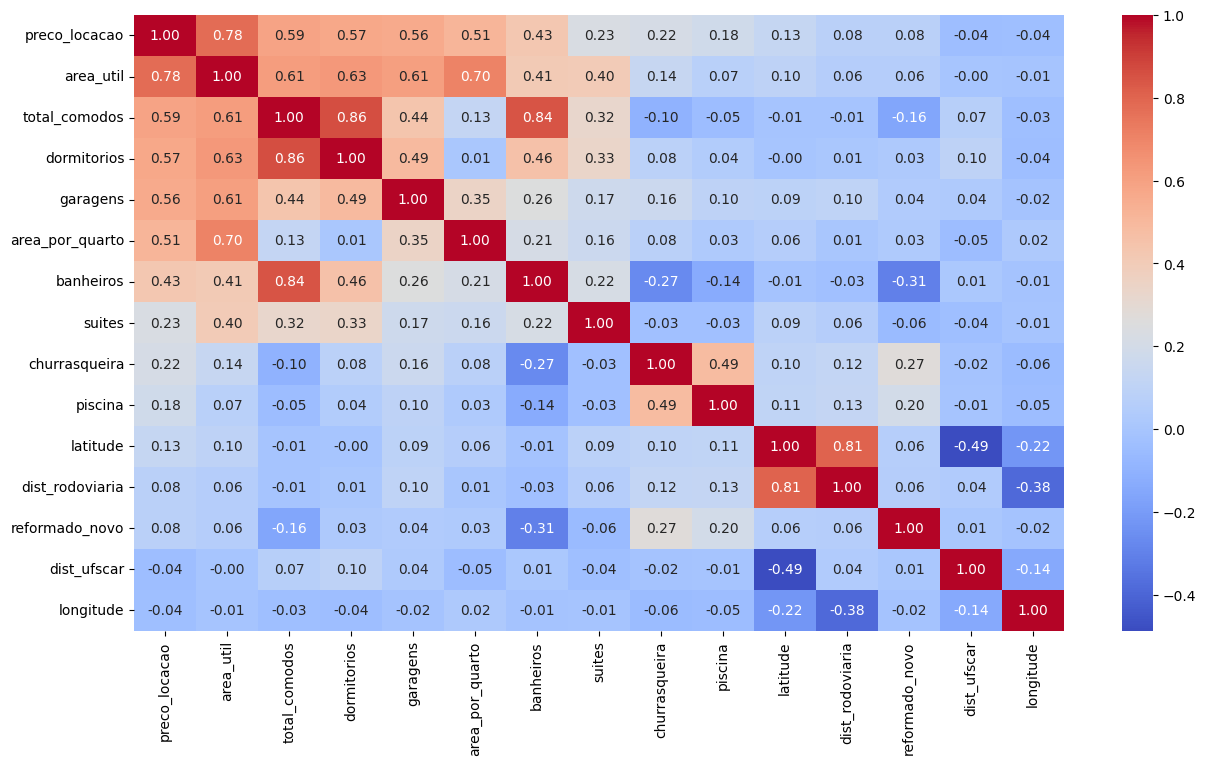

In [51]:
# Calcula a correlação de todas as numéricas
correlacao = df.corr(numeric_only=True)

# Pega as 10 colunas com maior correlação com 'preco_locacao' 
# (pegando os valores absolutos para considerar correlações negativas fortes também)
top_colunas = correlacao['preco_locacao'].abs().nlargest(15).index

# Aumenta o tamanho da figura
plt.figure(figsize=(15, 8))

# Plota o heatmap APENAS dessas 10 colunas
sns.heatmap(df[top_colunas].corr(numeric_only=True), annot=True, fmt=".2f", cmap='coolwarm')
plt.show()

In [40]:
df.iloc[0]

fonte                         cardinali
titulo             Apartamento - Padrão
tipo                        apartamento
subtipo                          padrao
finalidade                      locacao
preco_locacao                    1334.0
preco_venda                         NaN
bairro                           centro
dormitorios                           1
suites                                0
banheiros                             1
garagens                              0
area_util                          38.0
descricao                             -
latitude                     -22.022019
longitude                    -47.892932
reformado_novo                        0
mobiliado                             0
piscina                               0
churrasqueira                         0
total_comodos                         2
area_por_quarto                    38.0
dist_centro                    0.564712
dist_ufscar                    4.395734
dist_usp                       1.754654


## 4. Modelagem

### 4.1 Features e Pré-processador

`bairro` e `tipo` são codificados com **Target Encoding** (substitui a categoria pela média do alvo naquele grupo), evitando alta cardinalidade. As demais features numéricas passam direto (`remainder='passthrough'`).

In [41]:
features_limpas = [
    'tipo', 'area_util', 'bairro', 'area_por_quarto', 'dist_centro', 
    'dist_ufscar', 'dist_usp', 'dist_rodoviaria', 'garagens', 
    'total_comodos', 'dormitorios', 'banheiros', 'suites', 'reformado_novo', 
    'latitude', 'longitude'
]

X = df[features_limpas].copy()
y = df['preco_locacao'].copy()

preprocessor = ColumnTransformer(
    transformers=[
        ('bairro_enc', TargetEncoder(random_state=42), ['bairro']),
        ('tipo_enc', TargetEncoder(random_state=42), ['tipo']),
    ],
    remainder='passthrough'
)

### 4.2 LightGBM — Baseline

Avaliação inicial com hiperparâmetros padrão usando **cross-validation 5-fold**. O alvo é transformado com `log1p` para reduzir o efeito de outliers de preço no treinamento.

In [42]:
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', TransformedTargetRegressor(
        regressor=LGBMRegressor(
            n_estimators=300, 
            learning_rate=0.05, 
            max_depth=7, 
            num_leaves=31, 
            random_state=42, 
            n_jobs=-1,
            objective='mae',
            verbose=-1
        ),
        func=np.log1p, inverse_func=np.expm1
    ))
])

kf = KFold(n_splits=5, shuffle=True, random_state=42)
res = cross_validate(pipe, X, y, cv=kf, scoring={'mae': 'neg_mean_absolute_error', 'r2': 'r2'})

print("="*60)
print(f"LightGBM - ALVO: ALUGUEL (preco_locacao)")
print("-" * 60)
print(f"MAE Médio: R$ {-res['test_mae'].mean():.2f}")
print(f"MAE Folds: {-np.round(res['test_mae'], 2)}")
print("-" * 60)
print(f"R² Médio:  {res['test_r2'].mean():.3f}")
print(f"R² Folds:  {np.round(res['test_r2'], 3)}")
print("="*60)

/Users/josemaiadeoliveira/rentiq/am/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/josemaiadeoliveira/rentiq/am/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/josemaiadeoliveira/rentiq/am/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/josemaiadeoliveira/rentiq/am/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


LightGBM - ALVO: ALUGUEL (preco_locacao)
------------------------------------------------------------
MAE Médio: R$ 522.35
MAE Folds: [551.9  549.74 521.03 485.06 504.01]
------------------------------------------------------------
R² Médio:  0.695
R² Folds:  [0.713 0.724 0.654 0.637 0.747]


/Users/josemaiadeoliveira/rentiq/am/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


### 4.3 LightGBM — Otimização de Hiperparâmetros (Optuna)

Busca bayesiana com **50 trials** (10-fold CV por trial). Parâmetros otimizados: `n_estimators`, `learning_rate`, `max_depth`, `num_leaves`, `subsample`, `colsample_bytree`, `reg_alpha`, `reg_lambda`.

In [43]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 2000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'num_leaves': trial.suggest_int('num_leaves', 15, 127),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'random_state': 42,
        'n_jobs': -1,
        'objective': 'mae',
        'verbose': -1,
    }

    pipe_opt = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', TransformedTargetRegressor(
            regressor=LGBMRegressor(**params),
            func=np.log1p, inverse_func=np.expm1
        ))
    ])

    kf = KFold(n_splits=10, shuffle=True, random_state=42)
    scores = cross_validate(pipe_opt, X, y, cv=kf, scoring='neg_mean_absolute_error')
    return -scores['test_score'].mean()

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("="*60)
print("Melhores hiperparâmetros encontrados:")
print("-" * 60)
for k, v in study.best_params.items():
    print(f"  {k:22s}: {v}")
print(f"\nMelhor MAE: R$ {study.best_value:.2f}")
print("="*60)

  0%|          | 0/50 [00:00<?, ?it/s]/Users/josemaiadeoliveira/rentiq/am/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/josemaiadeoliveira/rentiq/am/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/josemaiadeoliveira/rentiq/am/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/josemaiadeoliveira/rentiq/am/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/josemaiadeoliveira/rentiq/am/.venv/lib/python3.12/site-packages/sklearn/uti

Melhores hiperparâmetros encontrados:
------------------------------------------------------------
  n_estimators          : 1740
  learning_rate         : 0.07014488236049812
  max_depth             : 6
  num_leaves            : 51
  min_child_samples     : 14
  subsample             : 0.7987071268107304
  colsample_bytree      : 0.5462602406226379
  reg_alpha             : 0.010841302297144792
  reg_lambda            : 0.003008583968145093

Melhor MAE: R$ 498.45


### 4.4 Random Forest — Otimização de Hiperparâmetros (Optuna)

**200 trials** com 5-fold CV. Parâmetros otimizados: `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`, `max_features`.

In [44]:
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 5, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 15),
        'max_features': trial.suggest_float('max_features', 0.3, 1.0),
        'random_state': 42,
        'n_jobs': -1,
    }

    pipe_rf = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', TransformedTargetRegressor(
            regressor=RandomForestRegressor(**params),
            func=np.log1p, inverse_func=np.expm1
        ))
    ])

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_validate(pipe_rf, X, y, cv=kf, scoring='neg_mean_absolute_error')
    return -scores['test_score'].mean()

study_rf = optuna.create_study(direction='minimize')
study_rf.optimize(objective_rf, n_trials=200, show_progress_bar=True)

print("="*60)
print("Random Forest - Melhores hiperparâmetros:")
print("-" * 60)
for k, v in study_rf.best_params.items():
    print(f"  {k:22s}: {v}")
print(f"\nMelhor MAE: R$ {study_rf.best_value:.2f}")
print("="*60)

Best trial: 137. Best value: 527.39: 100%|██████████| 200/200 [03:41<00:00,  1.11s/it] 

Random Forest - Melhores hiperparâmetros:
------------------------------------------------------------
  n_estimators          : 202
  max_depth             : 19
  min_samples_split     : 5
  min_samples_leaf      : 1
  max_features          : 0.5293514739862866

Melhor MAE: R$ 527.39


### 4.5 Random Forest Otimizado — Avaliação Final

In [45]:
best_rf = study_rf.best_params
best_rf.update({'random_state': 42, 'n_jobs': -1})

pipe_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', TransformedTargetRegressor(
        regressor=RandomForestRegressor(**best_rf),
        func=np.log1p, inverse_func=np.expm1
    ))
])

kf = KFold(n_splits=5, shuffle=True, random_state=42)
res_rf = cross_validate(pipe_rf, X, y, cv=kf, scoring={'mae': 'neg_mean_absolute_error', 'r2': 'r2'})

print("="*60)
print(f"Random Forest OTIMIZADO - ALVO: ALUGUEL (preco_locacao)")
print("-" * 60)
print(f"MAE Médio: R$ {-res_rf['test_mae'].mean():.2f}")
print(f"MAE Folds: {-np.round(res_rf['test_mae'], 2)}")
print("-" * 60)
print(f"R² Médio:  {res_rf['test_r2'].mean():.3f}")
print(f"R² Folds:  {np.round(res_rf['test_r2'], 3)}")
print("="*60)

Random Forest OTIMIZADO - ALVO: ALUGUEL (preco_locacao)
------------------------------------------------------------
MAE Médio: R$ 527.39
MAE Folds: [535.76 571.73 525.45 470.88 533.13]
------------------------------------------------------------
R² Médio:  0.688
R² Folds:  [0.718 0.701 0.651 0.637 0.734]


### 4.6 LightGBM Otimizado — Avaliação Final

In [46]:
best = study.best_params
best.update({'random_state': 42, 'n_jobs': -1, 'objective': 'mae', 'verbose': -1})

pipe_l = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', TransformedTargetRegressor(
        regressor=LGBMRegressor(**best),
        func=np.log1p, inverse_func=np.expm1
    ))
])

kf = KFold(n_splits=10, shuffle=True, random_state=42)
res_opt = cross_validate(pipe_l, X, y, cv=kf, scoring={'mae': 'neg_mean_absolute_error', 'r2': 'r2'})

pipe_l.fit(X, y)

print("="*60)
print(f"LightGBM OTIMIZADO - ALVO: ALUGUEL (preco_locacao)")
print("-" * 60)
print(f"MAE Médio: R$ {-res_opt['test_mae'].mean():.2f}")
print(f"MAE Folds: {-np.round(res_opt['test_mae'], 2)}")
print("-" * 60)
print(f"R² Médio:  {res_opt['test_r2'].mean():.3f}")
print(f"R² Folds:  {np.round(res_opt['test_r2'], 3)}")
print("="*60)

/Users/josemaiadeoliveira/rentiq/am/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/josemaiadeoliveira/rentiq/am/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/josemaiadeoliveira/rentiq/am/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/josemaiadeoliveira/rentiq/am/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/josemaiadeoliveira/rentiq/am/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X 

LightGBM OTIMIZADO - ALVO: ALUGUEL (preco_locacao)
------------------------------------------------------------
MAE Médio: R$ 498.45
MAE Folds: [460.63 617.49 618.7  474.47 497.82 434.03 505.49 432.4  491.04 452.46]
------------------------------------------------------------
R² Médio:  0.717
R² Folds:  [0.775 0.725 0.602 0.809 0.68  0.717 0.63  0.647 0.78  0.806]


### 4.7 KNN — Baseline de Comparação

Modelo de k-vizinhos mais próximos como referência simples. Requer `StandardScaler` pois é sensível à escala das features.

In [47]:
pipe_knn = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler()),
    ('regressor', TransformedTargetRegressor(
        regressor=KNeighborsRegressor(n_neighbors=7, weights='distance', n_jobs=-1),
        func=np.log1p, inverse_func=np.expm1
    ))
])

kf = KFold(n_splits=5, shuffle=True, random_state=42)
res_knn = cross_validate(pipe_knn, X, y, cv=kf, scoring={'mae': 'neg_mean_absolute_error', 'r2': 'r2'})

print("="*60)
print(f"KNN - ALVO: ALUGUEL (preco_locacao)")
print("-" * 60)
print(f"MAE Médio: R$ {-res_knn['test_mae'].mean():.2f}")
print(f"MAE Folds: {-np.round(res_knn['test_mae'], 2)}")
print("-" * 60)
print(f"R² Médio:  {res_knn['test_r2'].mean():.3f}")
print(f"R² Folds:  {np.round(res_knn['test_r2'], 3)}")
print("="*60)

KNN - ALVO: ALUGUEL (preco_locacao)
------------------------------------------------------------
MAE Médio: R$ 593.66
MAE Folds: [614.53 633.83 592.71 522.07 605.18]
------------------------------------------------------------
R² Médio:  0.607
R² Folds:  [0.638 0.611 0.582 0.587 0.618]


## 5. Importância das Features

Peso relativo de cada feature no modelo LightGBM otimizado (normalizado para somar 1). Quanto maior a barra, mais relevante a feature para prever o preço.

In [48]:
pipe_l.fit(X, y)
feat_names = ['bairro_encoded', 'tipo_encoded'] + [c for c in X.columns if c not in ['bairro', 'tipo']]
importances = pipe_l.named_steps['regressor'].regressor_.feature_importances_
importances = importances / importances.sum()

print("\n=== Peso das Features no Preço (LightGBM) ===")
for n, i in sorted(zip(feat_names, importances), key=lambda x: -x[1]):
    if i > 0.001:
        bar = '█' * int(i * 100)
        print(f"  {n:22s}: {i:.4f} {bar}")


=== Peso das Features no Preço (LightGBM) ===
  area_por_quarto       : 0.1241 ████████████
  area_util             : 0.1112 ███████████
  bairro_encoded        : 0.1031 ██████████
  longitude             : 0.0833 ████████
  dist_ufscar           : 0.0797 ███████
  latitude              : 0.0796 ███████
  dist_usp              : 0.0783 ███████
  dist_centro           : 0.0739 ███████
  dist_rodoviaria       : 0.0727 ███████
  tipo_encoded          : 0.0552 █████
  suites                : 0.0309 ███
  total_comodos         : 0.0305 ███
  garagens              : 0.0299 ██
  banheiros             : 0.0248 ██
  dormitorios           : 0.0176 █
  reformado_novo        : 0.0050 


## 6. Exportação do Modelo

Salva o pipeline completo (pré-processador + modelo) com `joblib` para uso na API de predição.

In [49]:
import joblib
from pathlib import Path

model_dir = Path('../models')
model_dir.mkdir(exist_ok=True)
joblib.dump(pipe_l, model_dir / 'modelo_aluguel.pkl')
print("Modelo salvo em ../models/modelo_aluguel.pkl")

Modelo salvo em ../models/modelo_aluguel.pkl


## 7. Validação com Imóveis Reais

Teste manual com 3 imóveis conhecidos de São Carlos para verificar se as predições fazem sentido na prática. O valor real do Vila Monteiro (Cardinali) serve como âncora de calibração.

In [50]:
KM_DEGREE = 111
CENTRO_LAT, CENTRO_LON = -22.0174, -47.8908
UFSCAR_LAT, UFSCAR_LON = -21.9839, -47.8822
USP_CAMPUS1_LAT, USP_CAMPUS1_LON = -22.0063, -47.8946
RODOVIARIA_LAT, RODOVIARIA_LON = -22.0304, -47.8823

EMBARE_LAT, EMBARE_LON = -21.9960, -47.8560
VILA_MONTEIRO_LAT, VILA_MONTEIRO_LON = -22.0135, -47.8960

def calc_dist(lat, lon, ref_lat, ref_lon):
    return np.sqrt((lat - ref_lat)**2 + (lon - ref_lon)**2) * KM_DEGREE

imoveis = pd.DataFrame([
    {
        'nome': 'Jardim Embaré - 2q, 1ban, 54m²',
        'tipo': 'apartamento',
        'area_util': 54, 'bairro': 'jardim embare', 'dormitorios': 2, 'banheiros': 1,
        'garagens': 1, 'suites': 0,
        'reformado_novo': 0,
        'total_comodos': 3, 'area_por_quarto': 27,
        'latitude': EMBARE_LAT, 'longitude': EMBARE_LON,
        'dist_centro': calc_dist(EMBARE_LAT, EMBARE_LON, CENTRO_LAT, CENTRO_LON),
        'dist_ufscar': calc_dist(EMBARE_LAT, EMBARE_LON, UFSCAR_LAT, UFSCAR_LON),
        'dist_usp': calc_dist(EMBARE_LAT, EMBARE_LON, USP_CAMPUS1_LAT, USP_CAMPUS1_LON),
        'dist_rodoviaria': calc_dist(EMBARE_LAT, EMBARE_LON, RODOVIARIA_LAT, RODOVIARIA_LON),
    },
    {
        'nome': 'Centro - 2q, 1ban, 50m²',
        'tipo': 'apartamento',
        'area_util': 50, 'bairro': 'centro', 'dormitorios': 2, 'banheiros': 1,
        'garagens': 0, 'suites': 0,
        'reformado_novo': 1,
        'total_comodos': 3, 'area_por_quarto': 25,
        'latitude': CENTRO_LAT, 'longitude': CENTRO_LON,
        'dist_centro': 0,
        'dist_ufscar': calc_dist(CENTRO_LAT, CENTRO_LON, UFSCAR_LAT, UFSCAR_LON),
        'dist_usp': calc_dist(CENTRO_LAT, CENTRO_LON, USP_CAMPUS1_LAT, USP_CAMPUS1_LON),
        'dist_rodoviaria': calc_dist(CENTRO_LAT, CENTRO_LON, RODOVIARIA_LAT, RODOVIARIA_LON),
    },
    {
        'nome': 'Vila Monteiro - 3q, 2ban, 95m² (Cardinali 238063)',
        'tipo': 'apartamento',
        'area_util': 95, 'bairro': 'vila monteiro', 'dormitorios': 3, 'banheiros': 2,
        'garagens': 2, 'suites': 1,
        'reformado_novo': 0,
        'total_comodos': 5, 'area_por_quarto': 95/3,
        'latitude': VILA_MONTEIRO_LAT, 'longitude': VILA_MONTEIRO_LON,
        'dist_centro': calc_dist(VILA_MONTEIRO_LAT, VILA_MONTEIRO_LON, CENTRO_LAT, CENTRO_LON),
        'dist_ufscar': calc_dist(VILA_MONTEIRO_LAT, VILA_MONTEIRO_LON, UFSCAR_LAT, UFSCAR_LON),
        'dist_usp': calc_dist(VILA_MONTEIRO_LAT, VILA_MONTEIRO_LON, USP_CAMPUS1_LAT, USP_CAMPUS1_LON),
        'dist_rodoviaria': calc_dist(VILA_MONTEIRO_LAT, VILA_MONTEIRO_LON, RODOVIARIA_LAT, RODOVIARIA_LON),
    },
])

precos = pipe_l.predict(imoveis[features_limpas])
for i, row in imoveis.iterrows():
    print(f"{row['nome']}")
    print(f"  Aluguel previsto: R$ {precos[i]:.2f}")

print(f"\nValor real Vila Monteiro (Cardinali): R$ 2.000,00 (aluguel)")
print(f"  Total no site: R$ 2.792,85 (aluguel + cond R$660 + IPTU R$132,85)")

Jardim Embaré - 2q, 1ban, 54m²
  Aluguel previsto: R$ 1233.84
Centro - 2q, 1ban, 50m²
  Aluguel previsto: R$ 1284.86
Vila Monteiro - 3q, 2ban, 95m² (Cardinali 238063)
  Aluguel previsto: R$ 2381.15

Valor real Vila Monteiro (Cardinali): R$ 2.000,00 (aluguel)
  Total no site: R$ 2.792,85 (aluguel + cond R$660 + IPTU R$132,85)


/Users/josemaiadeoliveira/rentiq/am/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
